# Practical backtesting for Kalshi, with h5i-db

Its sibling article, [Practical backtesting for
Polymarket](practical_backtesting_for_polymarket.ipynb), ended on a number: a
taker there gives up about a seventh of a cent per share to cross the spread,
and a rule that earns less than that loses however good its signal looks.

Kalshi is the other large prediction market, and the same sentence is only
half true there. It is a CFTC-regulated exchange rather than an on-chain
venue, it quotes in whole cents, and it charges a fee that most venues do not:
one proportional to `p * (1 - p)`, the variance of a coin flip, so it is
heaviest exactly where a contract is most uncertain. On the markets below that
fee is *larger than the spread*, which changes where a strategy can afford to
trade and, as it turns out, whether it can afford to trade at all.

This assumes the same background as its sibling: what a YES contract is, why
YES plus NO must sum to a dollar, and why "the price" is several different
numbers depending on the question. None of that is repeated. What is new here
is the venue, its fee, and a data source that needs no account:

1. **Get real Kalshi data**, from the exchange's own public API.
2. **Measure the toll** a taker pays: half the spread, plus the fee.
3. **Write a strategy** as an event-driven callback, run it, and read the
   result against that toll rather than against zero.

The database is [h5i-db](https://github.com/h5i-dev/h5i-db), an embedded,
versioned time-series store with an event-driven backtest engine built in.

In [1]:
import collections
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
from IPython.display import display

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

print(f"h5i-db {h5i_db.__version__}")

h5i-db 0.1.3


---

# 1. Real Kalshi books, from the exchange

The Polymarket study needed a third-party tick capture published on Kaggle,
because the venue does not serve its own history. Kalshi does. Three public,
unauthenticated endpoints carry everything this article uses, and
`cookbook_utils.kalshi_api` wraps them in a Parquet cache so a re-run is
offline after the first call.

| endpoint | gives | used for |
|---|---|---|
| `/markets` | definitions, close time, settlement time, **the exchange's own result** | market specs and ground truth |
| `/candlesticks` | one row per minute, carrying that minute's closing **bid and ask** | the book |
| `/markets/trades` | every print, with size and which side crossed | the tape |

Kalshi's vocabulary is worth thirty seconds. A **series** is a recurring
question (`KXHIGHNY`, the daily high temperature in New York). An **event** is
one instance of it (`KXHIGHNY-26AUG01`). A **market** is one mutually
exclusive answer within that event, and it is the thing you trade: a ticker,
a YES side and a NO side. Fetching by event therefore gives a whole ladder of
related contracts rather than an arbitrary basket, which is what we want.

In [2]:
EVENTS = ["KXHIGHNY-26JUL30", "KXHIGHNY-26JUL31", "KXHIGHNY-26AUG01"]

markets = cu.kalshi_markets(EVENTS)
ladder = markets.to_pandas().query("result in ('yes', 'no')").reset_index(drop=True)
print(f"{len(ladder)} settled markets across {len(EVENTS)} days, "
      f"{ladder.volume.sum():,.0f} contracts traded\n")
print(ladder[["ticker", "subtitle", "close_time", "settlement_ts", "result", "volume"]]
      .to_string(index=False))

18 settled markets across 3 days, 475,728 contracts traded

                ticker     subtitle                close_time                    settlement_ts result   volume
KXHIGHNY-26JUL30-B79.5   79° to 80° 2026-07-31 04:59:00+00:00 2026-07-31 12:01:13.740967+00:00     no 29271.25
KXHIGHNY-26JUL30-B77.5   77° to 78° 2026-07-31 04:59:00+00:00 2026-07-31 12:01:13.740967+00:00     no 67159.96
  KXHIGHNY-26JUL30-T84 85° or above 2026-07-31 04:59:00+00:00 2026-07-31 12:01:13.740967+00:00     no  2330.25
KXHIGHNY-26JUL30-B83.5   83° to 84° 2026-07-31 04:59:00+00:00 2026-07-31 12:01:13.740967+00:00     no  3533.86
KXHIGHNY-26JUL30-B81.5   81° to 82° 2026-07-31 04:59:00+00:00 2026-07-31 12:01:13.740967+00:00     no  7727.03
  KXHIGHNY-26JUL30-T77 76° or below 2026-07-31 04:59:00+00:00 2026-07-31 12:01:13.740967+00:00    yes 63103.53
KXHIGHNY-26JUL31-B82.5   82° to 83° 2026-08-01 04:59:00+00:00 2026-08-01 12:01:10.940990+00:00     no 42576.86
  KXHIGHNY-26JUL31-T82 81° or below 2026-08-01 04:59

Three days of one question, six strikes each, every one of them settled by the
exchange. Two properties of that shape matter later.

The `result` column is the exchange's own settlement, not a guess read off the
final price. Within each day exactly one market resolves YES, because the
strikes partition the possible temperatures, which also means the six are not
six independent bets.

`settlement_ts` is hours after `close_time`. Trading stops at 04:59 UTC and
the National Weather Service report that decides the outcome lands the
following morning. The engine will hold us to that distinction.

## The book, one minute at a time

A candle here is not the usual OHLCV bar. Each carries the closing bid and ask
of its minute, which is a quote rather than a trade, and that is what makes a
spread study possible at all from a public feed.

In [3]:
candles = cu.kalshi_candles(markets)
tape = cu.kalshi_trades(markets)
frame = candles.to_pandas()
print(f"candles {len(frame):,}   prints {tape.num_rows:,}")
print(f"window  {frame.ts.min():%Y-%m-%d %H:%M} .. {frame.ts.max():%Y-%m-%d %H:%M} UTC\n")
print(frame.head(4).to_string(index=False))

candles 21,471   prints 29,439
window  2026-07-29 14:01 .. 2026-08-02 04:56 UTC

                       ts                 ticker  yes_bid_close  yes_ask_close  price_close  volume  open_interest
2026-07-29 14:01:00+00:00 KXHIGHNY-26JUL30-B79.5           0.25           0.55          NaN     0.0            0.0
2026-07-29 14:01:00+00:00 KXHIGHNY-26JUL30-B77.5           0.14           0.24          NaN     0.0            0.0
2026-07-29 14:01:00+00:00   KXHIGHNY-26JUL30-T84           0.02           0.03         0.02    10.0           10.0
2026-07-29 14:01:00+00:00 KXHIGHNY-26JUL30-B83.5           0.08           0.09         0.05    26.0           26.0


### Three limits, all properties of the source

It is sampled, not continuous. One row per minute per market is the finest
this endpoint offers, so everything between two stamps is invisible: a rule
reading it sees sixty-second-old prices and cannot claim otherwise.

It carries no depth. A candle names the touch and nothing behind it. So this
data can price a *small* order crossing the spread and must refuse to price a
large one, and every run below trades ten contracts at a time. The tape says
how modest that is.

It is not always two-sided. Where the venue had no resting bid or no resting
ask, the candle still exists but quotes nothing tradeable, and those minutes
are dropped rather than filled in.

In [4]:
prints = tape.to_pandas()
two_sided = frame.dropna(subset=["yes_bid_close", "yes_ask_close"]).query(
    "0 < yes_bid_close < yes_ask_close < 1"
)
print(f"candles with a two-sided book: {len(two_sided):,} of {len(frame):,} "
      f"({len(two_sided) / len(frame):.0%})")
print(f"prints: median {prints['count'].median():,.0f} contracts, "
      f"{(prints['count'] <= 10).mean():.0%} of them 10 or fewer")

candles with a two-sided book: 18,028 of 21,471 (84%)
prints: median 4 contracts, 74% of them 10 or fewer


---

# 2. Into the database

## The markets

`MarketSpec` is the identity of one contract, and every field below is taken
from the exchange rather than assumed.

`tick_size` is a whole cent, which is Kalshi's price grid and coarser than
Polymarket's tenth of a cent. `expiration_ns` is when trading stopped, and the
engine rejects orders after it. `settlement_observable_ns` is when the result
became *knowable*; the engine refuses to value a position from it unless the
replay actually reached that instant, which is what stops the most
valuable-looking bug in prediction-market research. `winner_outcome` is an
index into `outcome_labels`, so `result == "yes"` becomes outcome 0.

In [5]:
specs = [
    venues.MarketSpec(
        instrument_id=row.ticker,
        venue="kalshi",
        outcome_labels=("YES", "NO"),
        tick_size=float(row.tick_size),
        lot_size=1.0,
        expiration_ns=int(pd.Timestamp(row.close_time).value),
        settlement_observable_ns=int(pd.Timestamp(row.settlement_ts).value),
        winner_outcome=0 if row.result == "yes" else 1,
        metadata={"subtitle": row.subtitle, "event": row.event_ticker},
    )
    for row in ladder.itertuples()
]
print(f"{len(specs)} specs; the winners were:")
for spec in specs:
    if spec.winner_outcome == 0:
        print(f"  {spec.instrument_id:<24} {spec.metadata['subtitle']}")

18 specs; the winners were:
  KXHIGHNY-26JUL30-T77     76° or below
  KXHIGHNY-26JUL31-B84.5   84° to 85°
  KXHIGHNY-26AUG01-B86.5   86° to 87°


## The book

The Polymarket article read its archive declaratively: an `ArchiveLayout`
literal described the vendor's file shape and `venues.ingest_archive` did the
rest. That works when the file is a book feed. A candle is not one, and
dressing it up as one with a layout would hide the single assumption this
study rests on, so the conversion is written out instead.

Each minute becomes one book event with exactly two levels: a bid at the
closing bid, an ask at the closing ask. The prices are the venue's. The sizes
are not, because the source has none, so they are set to a sentinel large
enough that a ten-contract order always fills at the touch. The assumption in
one line: any order in this study is small enough to be absorbed by whatever
was resting. The tape above says three quarters of real prints are ten
contracts or fewer, which makes it reasonable rather than verified.

In [6]:
quotes = two_sided.sort_values(["ts", "ticker"])
TOUCH_SIZE = 1e9  # not depth: a sentinel meaning "absorbs an order this small"

rows = {name: [] for name in venues.BOOK_DELTAS_SCHEMA.names}
for index, row in enumerate(quotes.itertuples(), start=1):
    for last, (side, price) in enumerate(
        (("buy", row.yes_bid_close), ("sell", row.yes_ask_close))
    ):
        rows["ts_init"].append(int(pd.Timestamp(row.ts).value))
        rows["ts_event"].append(int(pd.Timestamp(row.ts).value))
        rows["instrument_id"].append(row.ticker)
        rows["outcome"].append(0)  # the YES token; a NO bid is a YES ask
        rows["action"].append("snapshot")
        rows["side"].append(side)
        rows["price"].append(price)
        rows["size"].append(TOUCH_SIZE)
        rows["event_index"].append(index)  # both rows of a minute are one event
        rows["is_last"].append(bool(last))
        rows["source_vendor"].append("kalshi-candles-1m")

book = pa.table(
    {n: pa.array(v, type=venues.BOOK_DELTAS_SCHEMA.field(n).type) for n, v in rows.items()},
    schema=venues.BOOK_DELTAS_SCHEMA,
)
print(f"{book.num_rows:,} book rows from {len(quotes):,} minutes")

36,056 book rows from 18,028 minutes


The tape needs no such caveat. Every print is real: a price, a size, and which
side crossed, stamped by the exchange.

In [7]:
stamps = [int(pd.Timestamp(value).value) for value in prints.ts]
trades = pa.table(
    {
        "ts_init": pa.array(stamps, pa.timestamp("ns")),
        "ts_event": pa.array(stamps, pa.timestamp("ns")),
        "instrument_id": pa.array(prints.ticker.tolist(), pa.string()),
        "outcome": pa.array([0] * len(prints), pa.uint16()),
        "price": pa.array(prints.yes_price.tolist(), pa.float64()),
        "size": pa.array(prints["count"].tolist(), pa.float64()),
        # A taker who bought YES lifted the ask, so the aggressor was a buyer.
        "aggressor": pa.array(
            ["buy" if side == "yes" else "sell" for side in prints.taker_side], pa.string()
        ),
        "trade_id": pa.array(prints.trade_id.tolist(), pa.string()),
        "source_vendor": pa.array(["kalshi-trades"] * len(prints), pa.string()),
    },
    schema=venues.TRADES_SCHEMA,
)

db = h5i_db.Database(cu.fresh_db("article_kalshi"), create=True)
venues.write_markets(db, specs, note="exchange-settled results")
venues.ensure_tables(db, ["book_deltas", "trades"])
db.append("book_deltas", book)
db.append("trades", trades)
pin = db.snapshot(
    "real-v1",
    tables=["instruments", "book_deltas", "trades", "resolutions"],
    note="the pinned input for every run below",
)
print(f"book_deltas {book.num_rows:,} rows, trades {trades.num_rows:,} rows")
print(f"pinned as '{pin['name']}', checksum {pin['checksum'][:16]}")

book_deltas 36,056 rows, trades 29,439 rows
pinned as 'real-v1', checksum 21707d5ee1b52f1e


`db.snapshot(...)` pins a named, immutable view of those tables. Every run
below reads it by name, so each provably sees the same bytes and a result can
be reproduced months later even after tomorrow's data is appended.

## What the engine thinks of it

Before running anything, ask. `backtest.inspect` reads the tables a
configuration names and reports what execution claims they can support.

In [8]:
FEE_RATE = cu.KALSHI_TAKER_FEE_RATE


def configure(run_id, **execution):
    """One configuration shape, so every run below differs only where it says."""
    return backtest.BacktestConfig(
        run_id=run_id,
        data=backtest.DataConfig(strategy_id=run_id, snapshot="real-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=backtest.ExecutionConfig(fee_kind="kalshi", fee_rate=FEE_RATE, **execution),
        output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
        metadata={"venue": "kalshi", "source": "public api, 1m candles"},
    )


inspection = backtest.inspect(db, configure("probe"))
print(f"fidelity: {inspection.fidelity.value}   usable: {inspection.ok}")
for issue in inspection.issues:
    print(f"  [{issue.severity}] {issue.code}: {issue.message}")
print(f"capabilities: {dict(inspection.capabilities)}")

fidelity: snapshot_l2   usable: True
  [warning] snapshot_only: periodic snapshots cannot reconstruct queue transitions between events
capabilities: {'market_orders': True, 'limit_orders': True, 'queue_position': False, 'exact_intraday_path': False}


`snapshot_l2`, with a warning that queue transitions are not reconstructable
between events, and `queue_position: False` among the capabilities. That is
the honest description of minute candles, and it comes from the data rather
than from a promise. It becomes the last word of the article.

---

# 3. The toll

## Half the spread

`backtest.quote_panel` collapses `book_deltas` to the top of book: one row per
market per instant, which is also what the strategy will see.

In [9]:
panel = backtest.quote_panel(db, snapshot="real-v1")
panel["spread"] = panel.ask - panel.bid
panel["mid"] = (panel.bid + panel.ask) / 2
print(f"{len(panel):,} quotes across {panel.instrument_id.nunique()} markets\n")
print(panel[["bid", "ask", "spread", "mid"]].describe().round(4).to_string())

18,028 quotes across 18 markets

              bid         ask      spread         mid
count  18028.0000  18028.0000  18028.0000  18028.0000
mean       0.2440      0.2589      0.0149      0.2515
std        0.2315      0.2327      0.0186      0.2319
min        0.0100      0.0200      0.0100      0.0150
25%        0.0400      0.0500      0.0100      0.0450
50%        0.2000      0.2200      0.0100      0.2100
75%        0.3900      0.4100      0.0200      0.3950
max        0.9800      0.9900      0.5200      0.9850


The median spread is one cent, which is the minimum tick: for most of three
days these books were as tight as the exchange's price grid allows, and a
taker crossing one gives up half a cent per contract per side. The mean is
half again as wide, because the tail of wide moments is long. As the runs
below show, a rule that trades on movement tends to trade in exactly those
moments, so what it actually pays is nearer a cent than a half.

## And the fee

Then the exchange charges. Kalshi's published schedule prices a taker at

> `fee = ceil(0.07 * contracts * p * (1 - p))`, rounded up to the next cent

and the shape of it, not the rate, is what matters. `p * (1 - p)` is the
variance of a coin flip: zero at either certainty, maximum at fifty cents. The
exchange charges most for the contracts whose outcome is least known.

In [10]:
for price in (0.02, 0.05, 0.10, 0.25, 0.50, 0.75, 0.95):
    fee = cu.kalshi_taker_fee(price, 10)
    print(f"  10 contracts at {price:.2f}: fee ${fee:.2f}  "
          f"({fee / 10 * 100:.2f} cents each, {fee / (price * 10):.1%} of the stake)")

  10 contracts at 0.02: fee $0.02  (0.20 cents each, 10.0% of the stake)
  10 contracts at 0.05: fee $0.04  (0.40 cents each, 8.0% of the stake)
  10 contracts at 0.10: fee $0.07  (0.70 cents each, 7.0% of the stake)
  10 contracts at 0.25: fee $0.14  (1.40 cents each, 5.6% of the stake)
  10 contracts at 0.50: fee $0.18  (1.80 cents each, 3.6% of the stake)
  10 contracts at 0.75: fee $0.14  (1.40 cents each, 1.9% of the stake)
  10 contracts at 0.95: fee $0.04  (0.40 cents each, 0.4% of the stake)


Rounding up rather than to nearest is not a detail at this size, because the
rounding is a whole cent on a contract worth a dollar. One contract at two
cents owes about a seventh of a cent and pays one, seven times the posted
rate; a hundred contracts at the same price owe 13.7 cents and pay 14. Small
orders are expensive on Kalshi in a way the formula does not show.

## Both together, by price level

The two costs point in opposite directions across the book, which is the whole
geography of trading here. Cheap contracts have wide spreads relative to their
price but almost no fee; contracts near fifty cents are tight but taxed. Add
them and you get what a round-trip candidate has to beat.

In [11]:
levels = panel.assign(level=lambda f: f.mid.round(1)).groupby("level").agg(
    quotes=("mid", "size"),
    mean_mid=("mid", "mean"),
    half_spread=("spread", lambda series: series.mean() / 2),
)
levels["half_spread_c"] = levels.half_spread * 100
levels["fee_c"] = [cu.kalshi_taker_fee(price, 10) / 10 * 100 for price in levels.mean_mid]
levels["toll_c"] = levels.half_spread_c + levels.fee_c
print("cents per contract, one leg:\n")
print(levels.round(3).to_string())

cents per contract, one leg:

       quotes  mean_mid  half_spread  half_spread_c  fee_c  toll_c
level                                                             
0.0      4711     0.026        0.006          0.621    0.2   0.821
0.1      3031     0.088        0.007          0.704    0.6   1.304
0.2      2793     0.207        0.008          0.815    1.2   2.015
0.3      2402     0.292        0.009          0.890    1.5   2.390
0.4      1219     0.400        0.008          0.775    1.7   2.475
0.5      1717     0.496        0.008          0.763    1.8   2.563
0.6      1205     0.587        0.007          0.706    1.7   2.406
0.7       188     0.688        0.007          0.715    1.6   2.315
0.8       161     0.800        0.008          0.832    1.2   2.032
0.9       352     0.906        0.011          1.105    0.6   1.705
1.0       249     0.967        0.008          0.765    0.3   1.065


Read the last column. One leg costs between 0.8 cents in the tails and 2.6
cents in the middle, so a round trip on a one-dollar contract costs between
about 1.6 and 5.1 cents. And in the middle of the book the fee is the larger
half of it.

That inverts the Polymarket picture, where the crowded middle was the cheapest
place to trade and the tails were ruinous. Here the middle is the expensive
part: the dearest bucket in the table costs three times the cheapest, so the
same signal has to be three times as good to survive there. Where a Kalshi
strategy trades is a decision about cost before it is a decision about edge.

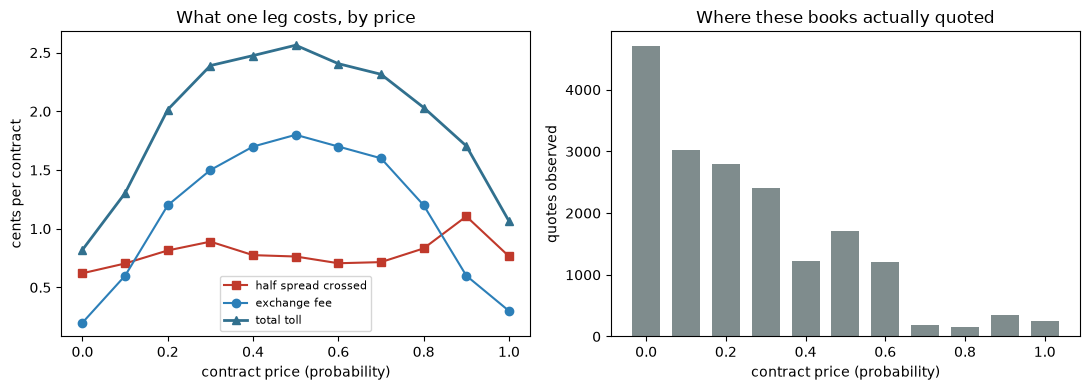

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(levels.index, levels.half_spread_c, marker="s", color="#c0392b",
             label="half spread crossed")
axes[0].plot(levels.index, levels.fee_c, marker="o", color="#2c7fb8", label="exchange fee")
axes[0].plot(levels.index, levels.toll_c, marker="^", color="#31708e", lw=2, label="total toll")
axes[0].set_title("What one leg costs, by price")
axes[0].set_xlabel("contract price (probability)")
axes[0].set_ylabel("cents per contract")
axes[0].legend(fontsize=8)
axes[1].bar(levels.index, levels.quotes, width=0.07, color="#7f8c8d")
axes[1].set_title("Where these books actually quoted")
axes[1].set_xlabel("contract price (probability)")
axes[1].set_ylabel("quotes observed")
fig.tight_layout()

---

# 4. A strategy, as a callback

A strategy here is an object whose methods the replay calls as it walks the
data forward, returning order commands. The form matters more than the rule:
anything path-dependent, anything reacting to its own fills or current
position, fits inside it, and three classic backtesting bugs are not
expressible in it. You cannot see the future, because you are handed one event
at a time. You cannot trade on a price the venue has not processed, because
commands are queued and meet the *next* book. You cannot lose track of your
position, because `event["position"]` is the engine's number, not yours.

The rule is the same breakout the Polymarket article used, generalised by one
parameter so the mirrored rule costs no extra code:

> `direction=+1`: buy when the price makes a new high over the last `lookback`
> observations, sell out on a new low. `direction=-1`: the reverse.

Start with breakout, because that is the one that had a real edge on
Polymarket.

In [13]:
class Trend(backtest.EventStrategy):
    """Buy a new extreme of the last `lookback` mids; sell out at the other."""

    def __init__(self, lookback=24, direction=1, quantity=10.0):
        self.lookback = lookback
        self.direction = direction
        self.quantity = quantity
        self.history = collections.defaultdict(collections.deque)
        self.orders_sent = 0

    def on_event(self, event):
        if event["type"] != "market":
            return None
        bid, ask = event["best_bid"], event["best_ask"]
        if bid is None or ask is None:
            return None  # one side of the book is empty; nothing to act on
        mid = (bid + ask) / 2.0
        window = self.history[(event["instrument_id"], event["outcome"])]

        command = None
        if len(window) == self.lookback:  # only act once the window is full
            high, low = max(window), min(window)
            entering = mid > high if self.direction > 0 else mid < low
            leaving = mid < low if self.direction > 0 else mid > high
            if event["position"] == 0 and entering:
                command = self._order(event, "buy", self.quantity, "entry")
            elif event["position"] > 0 and leaving:
                command = self._order(event, "sell", event["position"], "exit")

        # Record *after* deciding, so `window` always describes the past.
        window.append(mid)
        if len(window) > self.lookback:
            window.popleft()
        return command

    def _order(self, event, side, quantity, tag):
        self.orders_sent += 1
        return {
            "action": "submit",
            "client_order_id": f"order-{self.orders_sent}",
            "instrument_id": event["instrument_id"],
            "outcome": event["outcome"],
            "side": side,
            "quantity": quantity,
            "reduce_only": side == "sell",  # an exit may only shrink a position
            "tag": tag,
        }


LOOKBACK = 24
breakout = backtest.execute(db, configure(f"breakout-{LOOKBACK}"),
                            strategy=Trend(lookback=LOOKBACK, direction=1))
fills = breakout.fills.to_pandas()
summary = breakout.summary()
print(f"orders sent      {summary['orders']}")
print(f"fills            {len(fills)}")
print(f"contracts traded {fills.quantity.sum():,.0f}")
print(f"realized P&L     {summary['realized_pnl']:+.2f}")
print(f"fees paid        {fills.commission.sum():.2f}")

orders sent      663
fills            663
contracts traded 6,630
realized P&L     -149.03
fees paid        73.43


Every execution is a table, and `is_taker` is true on all of them: the rule
sends market orders, so it crossed the spread and paid the fee every time.

In [14]:
print(fills[["ts", "instrument_id", "side", "price", "quantity", "is_taker", "commission"]]
      .head(6).to_string(index=False))

                 ts          instrument_id side  price  quantity  is_taker  commission
2026-07-29 14:13:00   KXHIGHNY-26JUL30-T77  buy   0.60      10.0      True        0.17
2026-07-29 14:17:00 KXHIGHNY-26JUL30-B79.5  buy   0.16      10.0      True        0.10
2026-07-29 14:22:00 KXHIGHNY-26JUL30-B77.5  buy   0.26      10.0      True        0.14
2026-07-29 14:31:00   KXHIGHNY-26JUL30-T77 sell   0.53      10.0      True        0.18
2026-07-29 14:33:00   KXHIGHNY-26JUL30-T77  buy   0.60      10.0      True        0.17
2026-07-29 15:27:00   KXHIGHNY-26JUL30-T77 sell   0.54      10.0      True        0.18


## Where the money went

It lost. The useful question is *which* loss it is, because "the signal is
wrong" and "the signal is fine and the trading is too expensive" call for
completely different responses and look identical in a P&L line.

The fills can tell them apart. The fee is on every fill already. The spread
bill is computable by matching each fill back to the book it met. Subtract
both and what remains is the **gross edge**: what the rule would have made if
trading were free.

In [15]:
def decompose(result):
    """Split a run into gross edge, spread paid, fees paid, and what is left."""
    executions = result.fills.to_pandas()
    # A fill is stamped at the event that matched it, so this is an as-of join
    # backwards onto the book it actually met.
    matched = pd.merge_asof(
        executions.sort_values("ts"),
        panel[["instrument_id", "ts", "bid", "ask"]].sort_values("ts"),
        on="ts", by="instrument_id", direction="backward",
    )
    spread_cost = float(((matched.ask - matched.bid).abs() / 2 * matched.quantity).sum())
    fees = float(executions.commission.sum())
    pnl = float(result.summary()["realized_pnl"])
    contracts = float(executions.quantity.sum())
    return {
        "fills": len(executions), "contracts": contracts,
        "gross_edge": spread_cost + fees + pnl,
        "spread_cost": spread_cost, "fees": fees, "net_pnl": pnl,
        "gross_c": (spread_cost + fees + pnl) / contracts * 100,
        "spread_c": spread_cost / contracts * 100,
        "fee_c": fees / contracts * 100,
    }


parts = decompose(breakout)
budget = pd.DataFrame(
    [
        {"component": "gross edge (before costs)", "dollars": parts["gross_edge"]},
        {"component": "half spread crossed", "dollars": -parts["spread_cost"]},
        {"component": "exchange fees", "dollars": -parts["fees"]},
        {"component": "= realized P&L", "dollars": parts["net_pnl"]},
    ]
)
budget["cents_per_contract"] = budget.dollars / parts["contracts"] * 100
print(f"{parts['fills']} fills, {parts['contracts']:,.0f} contracts\n")
print(budget.round(3).to_string(index=False))

663 fills, 6,630 contracts

                component  dollars  cents_per_contract
gross edge (before costs)    -9.05              -0.137
      half spread crossed   -66.55              -1.004
            exchange fees   -73.43              -1.108
           = realized P&L  -149.03              -2.248


The gross edge is negative. Before paying a single cent of spread or fee,
this rule was already on the wrong side of the market: buying new highs in
these contracts lost money by itself.

That is a different diagnosis from the Polymarket run, where the same rule
earned a small positive gross edge and then handed slightly more of it back in
spread. There, trading less often was a real lever. Here it is not: scaling
down a negative number does not make it positive, and no execution improvement
rescues a signal pointing the wrong way.

It does, however, suggest an experiment.

---

# 5. Turning the rule around

If buying new highs loses gross, buying new *lows* should win gross on the
same data. That is not a new idea, it is the same rule with `direction=-1`,
and prediction markets on a slow physical process are a plausible home for it:
a temperature contract wanders around the forecast rather than trending.

Both rules, six window lengths each. Each setting needs a fresh strategy
instance, because a callback carries state.

In [16]:
LOOKBACKS = (6, 12, 24, 48, 96, 192)
runs, rows = {}, []
for name, direction in (("breakout", 1), ("fade", -1)):
    for lookback in LOOKBACKS:
        key = (name, lookback)
        runs[key] = (
            breakout if key == ("breakout", LOOKBACK)
            else backtest.execute(db, configure(f"{name}-{lookback}"),
                                  strategy=Trend(lookback=lookback, direction=direction))
        )
        rows.append({"rule": name, "lookback": lookback, **decompose(runs[key])})

sweep = pd.DataFrame(rows)
print(sweep[["rule", "lookback", "fills", "contracts", "gross_edge", "spread_cost",
             "fees", "net_pnl", "gross_c", "spread_c", "fee_c"]].round(3).to_string(index=False))

    rule  lookback  fills  contracts  gross_edge  spread_cost   fees  net_pnl  gross_c  spread_c  fee_c
breakout         6   1485    14850.0      -19.30       152.20 174.84  -346.34   -0.130     1.025  1.177
breakout        12   1024    10240.0       -9.00       102.00 118.11  -229.11   -0.088     0.996  1.153
breakout        24    663     6630.0       -9.05        66.55  73.43  -149.03   -0.137     1.004  1.108
breakout        48    393     3930.0       -6.75        41.35  42.46   -90.56   -0.172     1.052  1.080
breakout        96    232     2320.0       -4.65        26.65  25.59   -56.89   -0.200     1.149  1.103
breakout       192    113     1130.0       -1.25        13.75  12.31   -27.31   -0.111     1.217  1.089
    fade         6   1483    14830.0       22.20       148.30 173.42  -299.52    0.150     1.000  1.169
    fade        12   1032    10320.0       15.85       102.65 117.66  -204.46    0.154     0.995  1.140
    fade        24    663     6630.0       17.90        66.50  7

Four things to read, in order.

`gross_c` changes sign with the rule, as it had to: the fade earns roughly
what the breakout loses, because they are the same signal read in opposite
directions. The fade's edge is real and it *improves* with a longer window,
from about 0.15 cents a contract at six observations to about 0.85 at 192.

`spread_c` is flat near one cent whatever either rule does. It is a property
of the book, not of the strategy.

`fee_c` is flat near 1.1 cents, and it is the *larger* of the two costs. On
Polymarket the entire cost line was spread. Here the exchange takes more than
the market does.

`net_pnl` is negative in all twelve cells. The best fade earns 0.85 cents a
contract against a toll of about 2.3, so it recovers roughly a third of what
it costs to trade.

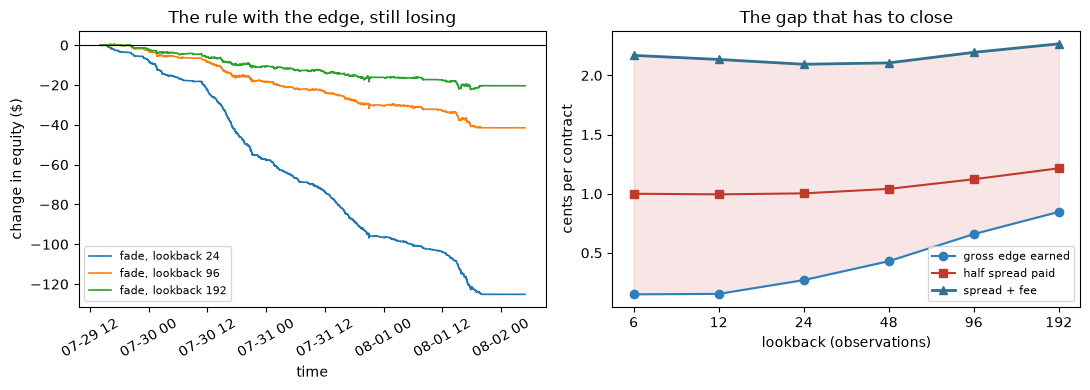

In [17]:
fade = sweep.query("rule == 'fade'")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lookback in (24, 96, 192):
    curve = runs[("fade", lookback)].equity.to_pandas().sort_values("ts")
    axes[0].plot(curve.ts, curve.equity - curve.equity.iloc[0], lw=1.2,
                 label=f"fade, lookback {lookback}")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("The rule with the edge, still losing")
axes[0].set_xlabel("time")
axes[0].set_ylabel("change in equity ($)")
axes[0].tick_params(axis="x", labelrotation=30)
axes[0].legend(fontsize=8)
axes[1].plot(fade.lookback, fade.gross_c, marker="o", color="#2c7fb8",
             label="gross edge earned")
axes[1].plot(fade.lookback, fade.spread_c, marker="s", color="#c0392b",
             label="half spread paid")
axes[1].plot(fade.lookback, fade.spread_c + fade.fee_c, marker="^", color="#31708e",
             lw=2, label="spread + fee")
axes[1].fill_between(fade.lookback, fade.gross_c, fade.spread_c + fade.fee_c,
                     color="#c0392b", alpha=0.12)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(list(LOOKBACKS))
axes[1].set_xticklabels([str(value) for value in LOOKBACKS])
axes[1].set_title("The gap that has to close")
axes[1].set_xlabel("lookback (observations)")
axes[1].set_ylabel("cents per contract")
axes[1].legend(fontsize=8)
fig.tight_layout()

The shaded band is the article in one picture: a real signal, a toll it never
reaches, and a gap that narrows with a longer window without ever closing.

Longer windows than 192 were tried and are not shown. Past that point the run
makes fewer than fifty fills across three days, and a cents-per-contract
figure computed from twenty-odd round trips is noise rather than evidence.
The temptation to keep extending until a cell turns positive is exactly what
the next section prices.

---

# 6. What would have to change

The decomposition says what a fix has to do. The fade at 192 earns its edge
and then pays two separate tolls, and they are not equally fixed.

In [18]:
best = fade.sort_values("net_pnl", ascending=False).iloc[0]
best_lookback = int(best.lookback)
result = runs[("fade", best_lookback)]
print(f"fade, lookback {best_lookback}: {int(best.fills)} fills, "
      f"{best.contracts:,.0f} contracts\n")
print(f"  earned                       {best.gross_c:+.3f} c/contract")
print(f"  paid in spread               {-best.spread_c:+.3f}")
print(f"  paid in fees                 {-best.fee_c:+.3f}")
print(f"  net                          {best.gross_c - best.spread_c - best.fee_c:+.3f}")
maker_fee_c = best.fee_c * 0.25  # Kalshi prices a resting order at a fraction
print(f"\n  crossing, at the maker fee   "
      f"{best.gross_c - best.spread_c - maker_fee_c:+.3f}   (fee cut, spread still paid)")
print(f"  posting, earning the spread  "
      f"{best.gross_c + best.spread_c - maker_fee_c:+.3f}   (the spread changes sign)")

fade, lookback 192: 114 fills, 1,140 contracts

  earned                       +0.846 c/contract
  paid in spread               -1.215
  paid in fees                 -1.052
  net                          -1.420

  crossing, at the maker fee   -0.631   (fee cut, spread still paid)
  posting, earning the spread  +1.798   (the spread changes sign)


Cutting the fee alone leaves it losing. Posting instead of crossing changes
the sign twice over: the spread stops being a cost and becomes income, and a
resting order is charged a fraction of an aggressive one: a quarter, in the
schedule current while this was written, which is the sort of number to look
up rather than remember. Both effects point the same way, and together they
are larger than anything the parameter sweep moved.

Which is exactly why this article stops here rather than reporting that
number. A resting order only earns the spread if it is *filled*, and whether
it is filled depends on where it sat in a queue that one-minute candles cannot
see. The engine agrees, and refuses:

In [19]:
maker = backtest.inspect(
    db, configure("maker-probe", maker_fee_rate=FEE_RATE * 0.25, queue_position=True)
)
print(f"usable: {maker.ok}")
for issue in maker.errors:
    print(f"  [{issue.severity}] {issue.code}: {issue.message}")
    print(f"      remedy: {issue.remediation}")

usable: False
  [error] unsupported_queue_claim: queue-position replay is not defensible with snapshot_l2 inputs
      remedy: provide tick L2 deltas plus trades, or disable queue_position


A backtest that answered anyway would have produced the most attractive
numbers in this article. Testing that idea needs delta-level data with
timestamps, which for Kalshi means recording the websocket while it happens,
because the exchange publishes no history of it. `h5i_db.capture` exists for
that, and it is a different article.

---

# 7. Settlement, and the gate in front of it

The other thing the engine does unasked. Two of the three event days resolve
inside this window and the third does not, so some positions can be valued at
their outcome and some cannot.

In [20]:
capture_end = int(pd.Timestamp(panel.ts.max()).value)
knowable = [spec for spec in specs if spec.settlement_observable_ns <= capture_end]
positions = result.positions.to_pandas()
print(f"markets whose result was knowable inside the window: {len(knowable)} of {len(specs)}")
print(f"positions held at the end:                           {len(positions)}")
print(f"of those, settled to their outcome:                  "
      f"{int(positions.settlement_pnl.notna().sum())}")
warning = result.run.to_pandas().warnings.iloc[0]
if isinstance(warning, str) and warning:
    print(f"\nthe engine's own words:\n  {warning.split(';')[0][:200]}")

markets whose result was knowable inside the window: 12 of 18
positions held at the end:                           14
of those, settled to their outcome:                  7

the engine's own words:
  KXHIGHNY-26AUG01-B82.5 outcome 0 left unsettled: the run simulated through 1785646529848625000 but this market resolved at 1785672070941764000


The refused ones are the last day's markets, which the National Weather
Service settled the morning after the data ends. Marking those positions to
their eventual outcome would have booked a profit nobody trading this window
could have collected, and it is the single most flattering mistake available
in prediction-market research. The check is one field on the spec and a
comparison the engine makes for you.

In [21]:
print(db.sql(
    """
    SELECT i.instrument_id,
           to_timestamp_nanos(min(i.expiration_ns))               AS stopped_trading,
           to_timestamp_nanos(min(i.settlement_observable_ns))    AS result_knowable,
           max(b.ts_init)                                         AS last_book_event
    FROM instruments AS i
    JOIN book_deltas AS b ON b.instrument_id = i.instrument_id
    GROUP BY i.instrument_id
    ORDER BY result_knowable DESC
    LIMIT 4
    """
).to_pandas().to_string(index=False))

         instrument_id     stopped_trading            result_knowable     last_book_event
KXHIGHNY-26AUG01-B88.5 2026-08-02 04:59:00 2026-08-02 12:01:10.941764 2026-08-01 20:13:00
KXHIGHNY-26AUG01-B82.5 2026-08-02 04:59:00 2026-08-02 12:01:10.941764 2026-08-01 15:36:00
KXHIGHNY-26AUG01-B86.5 2026-08-02 04:59:00 2026-08-02 12:01:10.941764 2026-08-01 20:13:00
  KXHIGHNY-26AUG01-T89 2026-08-02 04:59:00 2026-08-02 12:01:10.941764 2026-08-01 03:25:00


---

# 8. Before believing any of it

Twelve settings were run, and the least bad was chosen to talk about. When a
search like that does produce a winner, the winner is partly the search.

The **deflated Sharpe ratio** prices that. It computes the Sharpe a worthless
strategy would be expected to reach by luck given how many trials produced it,
then asks how likely the observed Sharpe is to beat it.

In [22]:
curve = result.equity.to_pandas().sort_values("ts").equity.tolist()
returns = [
    (curve[i] - curve[i - 1]) / curve[i - 1] for i in range(1, len(curve)) if curve[i - 1]
]
for trials in (1, len(sweep)):
    deflated = quant.deflated_sharpe(returns, trials=trials)
    label = "claiming one trial" if trials == 1 else f"admitting {trials} trials"
    print(f"{label:<24} sharpe {deflated.sharpe:+.4f}  "
          f"benchmark {deflated.benchmark:+.4f}  P(genuine) {deflated.probability:.3f}")

claiming one trial       sharpe -0.0450  benchmark +0.0000  P(genuine) 0.001
admitting 12 trials      sharpe -0.0450  benchmark +0.0247  P(genuine) 0.000


Nothing here needs deflating: the Sharpe is negative, so no honest reading of
it survives either way. The number to keep is the benchmark, which is the
Sharpe a strategy with no edge would be *expected* to reach after twelve
trials. Any future run of this article that produces a winner has to clear
that line before it means anything, and the line moves with every setting
tried.

There is also a ceiling on what three days of one weather question could show
in principle. Six strikes a day partition one temperature, so a day is closer
to one bet than to six, and three days is closer to three than to eighteen.

## The run as one page

`result.report()` renders a run as a self-contained HTML document: no network
access when opened, no dependencies, openable in five years. It leads with
replay fidelity, the data pin and the warnings, before any performance figure,
because those decide whether the performance figure means anything. The status
banner says `periodic L2 snapshots` rather than something reassuring, which is
the honest description of minute candles.

In [23]:
report_path = Path(f"data/cache/kalshi-fade-{best_lookback}.html")
document = result.report(report_path, title=f"Kalshi fade, lookback {best_lookback}")
print(f"wrote {report_path} ({len(document) / 1024:.0f} KB, self-contained)")
display(result)

wrote data/cache/kalshi-fade-192.html (249 KB, self-contained)


{'run_id': 'fade-192',
 'fork': 'bt-fade-192',
 'digest': 'f4cef61265cc762e3836746b7eba41535c427e128687ae384d109b2f422dc454',
 'starting_cash': 100000.0,
 'final_cash': 99946.51,
 'realized_pnl': -16.19,
 'commissions': 11.99,
 'funding_paid': 0.0,
 'fills': 114,
 'orders': 114,
 'records_processed': 47467,
 'simulated_through_ns': 1785646529848625000,
 'equity_points': 4538,
 'settlement_applied': True,
 'coverage': None,
 'liquidations': 0,
 'rejected_for_margin': 0,
 'self_trades_prevented': 0,
 'calibration_samples': [],
 'set_operations': [],
 'forecasts': 0,
 'mark_points': 57814,
 'expirations': [{'instrument_id': 'KXHIGHNY-26JUL30-B77.5',
   'ts': 1785473940000000000},
  {'instrument_id': 'KXHIGHNY-26JUL30-B79.5', 'ts': 1785473940000000000},
  {'instrument_id': 'KXHIGHNY-26JUL30-B81.5', 'ts': 1785473940000000000},
  {'instrument_id': 'KXHIGHNY-26JUL30-B83.5', 'ts': 1785473940000000000},
  {'instrument_id': 'KXHIGHNY-26JUL30-T77', 'ts': 1785473940000000000},
  {'instrument_id': 'KXHIGHNY-26JUL30-T84', 'ts': 1785473940000000000},
  {'instrument_id': 'KXHIGHNY-26JUL31-B82.5', 'ts': 1785560340000000000},
  {'instrument_id': 'KXHIGHNY-26JUL31-B84.5', 'ts': 1785560340000000000},
  {'instrument_id': 'KXHIGHNY-26JUL31-B86.5', 'ts': 1785560340000000000},
  {'instrument_id': 'KXHIGHNY-26JUL31-B88.5', 'ts': 1785560340000000000},
  {'instrument_id': 'KXHIGHNY-26JUL31-T82', 'ts': 1785560340000000000},
  {'instrument_id': 'KXHIGHNY-26JUL31-T89', 'ts': 1785560340000000000}],
 'metrics': {'orders_submitted': 114,
  'orders_filled': 114,
  'orders_cancelled_unfilled': 0,
  'orders_rejected_margin': 0,
  'orders_rejected_risk': 0,
  'orders_rejected_self_trade': 0,
  'orders_rejected_naked_short': 0,
  'orders_rejected_expired': 0,
  'orders_rejected_post_only': 0,
  'orders_triggered': 0,
  'twap_slices': 0,
  'fills_taker': 114,
  'fills_maker': 0,
  'book_gaps': 0,
  'liquidations': 0,
  'set_operations': 0,
  'set_operations_rejected': 0,
  'instruments_expired': 12},
 'warnings': ['KXHIGHNY-26AUG01-B82.5 outcome 0 left unsettled: the run simulated through 1785646529848625000 but this market resolved at 1785672070941764000; booking it would be profit nobody trading this window could have collected',
  'KXHIGHNY-26AUG01-B84.5 outcome 0 left unsettled: the run simulated through 1785646529848625000 but this market resolved at 1785672070941764000; booking it would be profit nobody trading this window could have collected',
  'KXHIGHNY-26AUG01-B86.5 outcome 0 left unsettled: the run simulated through 1785646529848625000 but this market resolved at 1785672070941764000; booking it would be profit nobody trading this window could have collected',
  'KXHIGHNY-26AUG01-B88.5 outcome 0 left unsettled: the run simulated through 1785646529848625000 but this market resolved at 1785672070941764000; booking it would be profit nobody trading this window could have collected',
  'KXHIGHNY-26AUG01-T82 outcome 0 left unsettled: the run simulated through 1785646529848625000 but this market resolved at 1785672070941764000; booking it would be profit nobody trading this window could have collected'],
 'cached': False,
 'trial_digest': '8a09534f3216998db5c0821cb5c9fc3874857dc79cb987761c59109caf08ef9f'}

## Reproducing it

The one claim that has to hold whatever the result is. `verify()` re-executes
the stored configuration against the same pin and compares every result table
row by row. A callback carries state, so it needs a fresh instance: the one
that just ran has a full history buffer and would not start from the same
place.

In [24]:
verified = result.verify(strategy=Trend(lookback=best_lookback, direction=-1))
print(f"verified:        {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"data pin:        {result.config.data.snapshot}")

verified:        True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
data pin:        real-v1


In [25]:
db.close()

---

# What to take away

On Kalshi the fee is the larger half of the toll. Half a spread is about one
cent a contract on these books; the exchange's fee is about 1.1, and it peaks
at fifty cents where the spread is tightest. Any cost model that stops at the
spread understates the hurdle by more than half.

The toll has a geography, and it is the opposite of Polymarket's. There, the
crowded middle was cheap and the longshots were ruinous. Here, `p * (1 - p)`
makes the middle the expensive part and the tails nearly free. That single
fact should decide where a Kalshi strategy looks for edge before any signal is
written.

A losing backtest still tells you which loss it is. Splitting the result into
gross edge, spread and fee said the breakout rule was wrong-way, not mispriced
but wrong, while its mirror image had an edge that was merely too small. Those
two findings look identical in a P&L line and call for completely different
next steps.

The lever that mattered was not a parameter. Twelve settings moved the result
around without changing its sign. Not crossing the spread would change it
twice over, which is the difference between tuning a strategy and changing how
it trades.

Let the machine hold the caveats. It refused a queue-position claim the data
cannot support, refused to settle positions whose outcomes the replay never
reached, pinned the input so every run reads identical bytes, and put the
fidelity warning at the top of the report rather than in a footnote somebody
has to remember to write.

## Where to go next

- **Record the book:** Kalshi publishes no order-book history, so queue-aware
  work needs a recording made while it happens. `h5i_db.capture` connects,
  stamps arrival in nanoseconds, and writes frames unmodified.
- **Both sides of the ladder:** six strikes partitioning one temperature must
  sum to a dollar, and the arithmetic of that constraint is a study in itself.
- **Signals tables instead of callbacks:** a strategy expressed as a table of
  timestamped order intents gives up path-dependence and gains a content hash,
  which unlocks trial deduplication and `backtest.study` parameter searches;
  the sweep above would have been a one-liner.
- **Execution as a variable:** latency, order size against real depth, and
  posting versus crossing move a result more than most strategy changes do.

The cookbook this article is drawn from is at
[h5i-db-cookbook](https://github.com/h5i-dev/h5i-db-cookbook), with longer
treatments of each in `notebooks/05_prediction_markets/`.